# MobileNetV2 — Fine-tuning

Pretrained MobileNetV2 (ImageNet) з дофайн-тюнінгом для face anti-spoofing.

**Стратегія:** спочатку тренуємо тільки голову (freeze backbone), потім розмораживаємо всю мережу з меншим LR.

**Виходи:** `models/mobilenet_best.pth`

## Імпорти

In [ ]:
import numpy as np
import cv2
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import json
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.metrics import accuracy_score, roc_curve, auc, confusion_matrix

# Уніфікований вибір device: cuda > mps > cpu
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

print(f'PyTorch: {torch.__version__}  |  Device: {DEVICE}')


## Конфігурація

In [ ]:
DATASET_ROOT = Path('./datasets')
FRAMES_ROOT  = Path('./datasets/frames')
MODELS_DIR   = Path('./models')
MODELS_DIR.mkdir(exist_ok=True)

IMG_SIZE     = 128   # стандартний розмір для MobileNetV2
BATCH_SIZE   = 32
EPOCHS_HEAD  = 10   # Phase 1: тренуємо тільки голову
EPOCHS_FULL  = 20   # Phase 2: fine-tune всієї мережі
LR_HEAD      = 1e-3
LR_FULL      = 1e-4
WEIGHT_DECAY = 1e-4
NUM_WORKERS  = 0

PROTO_DIR = DATASET_ROOT / 'protocols'

PROTOCOLS = {
    'grandtest': ('attack-grandtest-allsupports-{}.txt', 'real-{}.txt'),
    'print':     ('attack-print-allsupports-{}.txt',     'real-{}.txt'),
    'mobile':    ('attack-mobile-allsupports-{}.txt',    'real-{}.txt'),
    'highdef':   ('attack-highdef-allsupports-{}.txt',   'real-{}.txt'),
    'fixed':     ('attack-grandtest-fixed-{}.txt',       'real-{}.txt'),
    'hand':      ('attack-grandtest-hand-{}.txt',        'real-{}.txt'),
}

print('Конфігурація готова')


## Dataset (той самий що в cnn_scratch)

In [ ]:
def read_protocol(proto_file):
    pf = Path(proto_file)
    if not pf.exists():
        return []
    with open(pf) as f:
        return [l.strip() for l in f if l.strip()]

def video_to_frames_dir(video_rel_path):
    p = Path(video_rel_path)
    return FRAMES_ROOT / p.parent / p.stem

class FaceDataset(Dataset):
    def __init__(self, attack_paths, real_paths, transform=None):
        self.samples  = []
        self.transform = transform
        video_idx = 0
        for vp in real_paths:
            fd = video_to_frames_dir(vp)
            for fp in (sorted(fd.glob('*.jpg')) if fd.exists() else []):
                self.samples.append((fp, 0, video_idx))
            video_idx += 1
        for vp in attack_paths:
            fd = video_to_frames_dir(vp)
            for fp in (sorted(fd.glob('*.jpg')) if fd.exists() else []):
                self.samples.append((fp, 1, video_idx))
            video_idx += 1
        self.n_videos = video_idx
        print(f'  Dataset: {len(self.samples)} кадрів, {video_idx} відео')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        fpath, label, vid_idx = self.samples[idx]
        img = cv2.imread(str(fpath))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        if self.transform:
            img = self.transform(img)
        return img, label, vid_idx

# ImageNet нормалізація (стандарт для pretrained моделей)
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

# ColorJitter прибрано — зміни кольору/яскравості потенційно маскують spoof-артефакти
# (моарé, субпікселі, зсуви gamut-у принтера) — саме те, що модель має навчитися ловити.
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

print('Dataset клас готовий')


## Завантаження даних

In [19]:
print('Train set:')
train_ds = FaceDataset(
    read_protocol(PROTO_DIR / 'attack-grandtest-allsupports-train.txt'),
    read_protocol(PROTO_DIR / 'real-train.txt'), transform=train_transform)

print('Devel set:')
devel_ds = FaceDataset(
    read_protocol(PROTO_DIR / 'attack-grandtest-allsupports-devel.txt'),
    read_protocol(PROTO_DIR / 'real-devel.txt'), transform=val_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
devel_loader = DataLoader(devel_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
print(f'Train batches: {len(train_loader)} | Devel batches: {len(devel_loader)}')

Train set:
  Dataset: 3575 кадрів, 360 відео
Devel set:
  Dataset: 3564 кадрів, 360 відео
Train batches: 112 | Devel batches: 112


## Модель MobileNetV2

In [20]:
backbone = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

# Замінюємо classifier голову
in_features = backbone.classifier[1].in_features  # 1280
backbone.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(in_features, 256),
    nn.ReLU(inplace=True),
    nn.Dropout(0.2),
    nn.Linear(256, 2)
)

model = backbone.to(DEVICE)

total  = sum(p.numel() for p in model.parameters())
print(f'Параметри: {total:,} всього')
print(f'Classifier head: {sum(p.numel() for p in model.classifier.parameters()):,}')

Параметри: 2,552,322 всього
Classifier head: 328,450


## Phase 1 — Тренуємо тільки голову (backbone frozen)

In [ ]:
def _compute_eer_value(y_true, y_scores):
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    fnr = 1 - tpr
    idx = np.nanargmin(np.abs(fnr - fpr))
    return float((fpr[idx] + fnr[idx]) / 2)

def _devel_video_eer(loader):
    model.eval()
    all_probs, all_labels, all_vids = [], [], []
    with torch.no_grad():
        for imgs, labels, vid_idx in loader:
            probs = torch.softmax(model(imgs.to(DEVICE)), dim=1)[:, 1].cpu().numpy()
            all_probs.extend(probs); all_labels.extend(labels.numpy()); all_vids.extend(vid_idx.numpy())
    all_probs = np.array(all_probs); all_labels = np.array(all_labels); all_vids = np.array(all_vids)
    vs, vl = [], []
    for v in np.unique(all_vids):
        m = all_vids == v
        vs.append(all_probs[m].mean()); vl.append(all_labels[m][0])
    return _compute_eer_value(np.array(vl), np.array(vs))

# ---------- Class weight для боротьби з дисбалансом real:attack ≈ 1:5 ----------
n_real   = sum(1 for s in train_ds.samples if s[1] == 0)
n_attack = sum(1 for s in train_ds.samples if s[1] == 1)
w_real   = n_attack / n_real if n_real > 0 else 1.0
class_weights = torch.tensor([w_real, 1.0], dtype=torch.float32).to(DEVICE)
print(f'Train: real={n_real} кадрів, attack={n_attack} кадрів → class_weights=[{w_real:.2f}, 1.00]')

# Заморожуємо backbone
for param in model.features.parameters():
    param.requires_grad = False

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Phase 1: trainable params = {trainable:,} (тільки голова)')

criterion  = nn.CrossEntropyLoss(weight=class_weights)
optimizer  = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),
                        lr=LR_HEAD, weight_decay=WEIGHT_DECAY)
scheduler  = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

history = {'train_loss':[], 'train_acc':[], 'devel_loss':[], 'devel_acc':[], 'devel_eer':[]}
best_eer, best_epoch = 1.0, 0   # ← вибираємо модель за МІНІМАЛЬНИМ EER на devel

def run_epoch(loader, train_mode):
    model.train(train_mode)
    total_loss, correct, total = 0.0, 0, 0
    ctx = torch.no_grad() if not train_mode else torch.enable_grad()
    with ctx:
        for imgs, labels, _ in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            if train_mode:
                optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, labels)
            if train_mode:
                loss.backward(); optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            correct    += (out.argmax(1) == labels).sum().item()
            total      += imgs.size(0)
    return total_loss/total, correct/total

print(f'\n--- Phase 1: {EPOCHS_HEAD} epochs ---')
for epoch in range(1, EPOCHS_HEAD + 1):
    tr_loss, tr_acc = run_epoch(train_loader, True)
    dv_loss, dv_acc = run_epoch(devel_loader, False)
    dv_eer = _devel_video_eer(devel_loader)
    scheduler.step()
    history['train_loss'].append(tr_loss); history['train_acc'].append(tr_acc)
    history['devel_loss'].append(dv_loss); history['devel_acc'].append(dv_acc)
    history['devel_eer'].append(dv_eer)
    if dv_eer < best_eer:
        best_eer, best_epoch = dv_eer, epoch
        torch.save(model.state_dict(), MODELS_DIR / 'mobilenet_best.pth')
    print(f'Epoch {epoch:02d}/{EPOCHS_HEAD}  train acc={tr_acc:.4f}  '
          f'devel acc={dv_acc:.4f} eer={dv_eer*100:.2f}%'
          + (f'  ← best (EER)' if epoch==best_epoch else ''))


## Phase 2 — Fine-tune всієї мережі

In [ ]:
# Розморожуємо весь backbone
for param in model.features.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Phase 2: trainable params = {trainable:,} (вся мережа)')

# Менший LR для backbone, більший для голови (criterion / class_weights успадковуємо з Phase 1)
optimizer = optim.Adam([
    {'params': model.features.parameters(),   'lr': LR_FULL * 0.1},
    {'params': model.classifier.parameters(), 'lr': LR_FULL}
], weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_FULL)

NUM_EPOCHS = EPOCHS_HEAD + EPOCHS_FULL
print(f'\n--- Phase 2: {EPOCHS_FULL} epochs ---')
for epoch in range(EPOCHS_HEAD + 1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, True)
    dv_loss, dv_acc = run_epoch(devel_loader, False)
    dv_eer = _devel_video_eer(devel_loader)
    scheduler.step()
    history['train_loss'].append(tr_loss); history['train_acc'].append(tr_acc)
    history['devel_loss'].append(dv_loss); history['devel_acc'].append(dv_acc)
    history['devel_eer'].append(dv_eer)
    if dv_eer < best_eer:
        best_eer, best_epoch = dv_eer, epoch
        torch.save(model.state_dict(), MODELS_DIR / 'mobilenet_best.pth')
    print(f'Epoch {epoch:02d}/{NUM_EPOCHS}  train acc={tr_acc:.4f}  '
          f'devel acc={dv_acc:.4f} eer={dv_eer*100:.2f}%'
          + (f'  ← best (EER)' if epoch==best_epoch else ''))

print(f'\nНайкраща модель: epoch {best_epoch}, devel EER={best_eer*100:.2f}%')


## Криві навчання

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
ep = range(1, len(history['train_loss'])+1)

axes[0].plot(ep, history['train_loss'], label='Train', lw=2)
axes[0].plot(ep, history['devel_loss'], label='Devel', lw=2)
axes[0].axvline(EPOCHS_HEAD, color='gray', ls=':', lw=1, label='Phase 1→2')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, history['train_acc'], label='Train', lw=2)
axes[1].plot(ep, history['devel_acc'], label='Devel', lw=2)
axes[1].axvline(EPOCHS_HEAD, color='gray', ls=':', lw=1, label='Phase 1→2')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(ep, [e*100 for e in history['devel_eer']], label='Devel EER', lw=2, color='tab:red')
axes[2].axvline(EPOCHS_HEAD, color='gray', ls=':', lw=1, label='Phase 1→2')
axes[2].axvline(best_epoch,  color='red',  ls='--', lw=1, label=f'Best epoch {best_epoch}')
axes[2].set_title('Devel EER (%) — критерій вибору моделі')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('EER %'); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle('MobileNetV2 Fine-tuning — Training Curves', fontsize=13)
plt.tight_layout()
plt.savefig('models/mobilenet_training.png', dpi=150)
plt.show()


## Оцінка на test set по протоколах

In [ ]:
model.load_state_dict(torch.load(MODELS_DIR / 'mobilenet_best.pth', map_location=DEVICE))
model.eval()

def get_video_scores(dataset):
    loader = DataLoader(dataset, batch_size=64, shuffle=False, num_workers=NUM_WORKERS)
    all_probs, all_labels, all_vids = [], [], []
    with torch.no_grad():
        for imgs, labels, vid_idx in loader:
            probs = torch.softmax(model(imgs.to(DEVICE)), dim=1)[:, 1].cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(labels.numpy())
            all_vids.extend(vid_idx.numpy())
    all_probs  = np.array(all_probs)
    all_labels = np.array(all_labels)
    all_vids   = np.array(all_vids)
    v_scores, v_labels = [], []
    for v in np.unique(all_vids):
        mask = all_vids == v
        v_scores.append(all_probs[mask].mean())
        v_labels.append(all_labels[mask][0])
    return np.array(v_scores), np.array(v_labels)

def compute_eer(y_true, y_scores):
    fpr, tpr, ths = roc_curve(y_true, y_scores)
    fnr = 1 - tpr
    idx = np.nanargmin(np.abs(fnr - fpr))
    return float((fpr[idx]+fnr[idx])/2), float(ths[idx])

def compute_hter(y_true, y_scores, threshold):
    p = (y_scores >= threshold).astype(int)
    return float((p[y_true==0].mean() + (1-p[y_true==1]).mean()) / 2)

# --- Test по протоколах з per-protocol threshold ---
print('Тест по протоколах (threshold підбирається для кожного під-протоколу окремо на його devel)...')
results = {}
for proto_name, (atk_tpl, real_tpl) in PROTOCOLS.items():
    print(f'\n  === {proto_name} ===')
    # 1) Devel → threshold
    atk_d  = read_protocol(PROTO_DIR / atk_tpl.format('devel'))
    real_d = read_protocol(PROTO_DIR / real_tpl.format('devel'))
    if not atk_d or not real_d:
        continue
    ds_d = FaceDataset(atk_d, real_d, transform=val_transform)
    vs_d, vl_d = get_video_scores(ds_d)
    eer_d, proto_threshold = compute_eer(vl_d, vs_d)
    print(f'  Devel: EER={eer_d*100:.2f}% → threshold={proto_threshold:.4f}')

    # 2) Test
    atk  = read_protocol(PROTO_DIR / atk_tpl.format('test'))
    real = read_protocol(PROTO_DIR / real_tpl.format('test'))
    if not atk or not real:
        continue
    ds = FaceDataset(atk, real, transform=val_transform)
    vs, vl = get_video_scores(ds)
    eer, _ = compute_eer(vl, vs)
    hter   = compute_hter(vl, vs, proto_threshold)
    fpr, tpr, _ = roc_curve(vl, vs)
    results[proto_name] = {
        'n': ds.n_videos,
        'acc': accuracy_score(vl, (vs >= proto_threshold).astype(int)),
        'auc': auc(fpr, tpr), 'eer': eer, 'hter': hter,
        'threshold': proto_threshold,
        'fpr': fpr, 'tpr': tpr, 'vs': vs, 'vl': vl
    }
    print(f'  Test:  EER={eer*100:.2f}%  HTER={hter*100:.2f}%  AUC={auc(fpr, tpr):.4f}')
print('\nDone!')


## Результати

In [25]:
print('\n' + '='*60)
print(f'{"Протокол":<12} {"N":>5} {"Acc":>7} {"AUC":>7} {"EER%":>7} {"HTER%":>8}')
print('-'*60)
for name, r in results.items():
    print(f'{name:<12} {r["n"]:>5} {r["acc"]:>7.4f} {r["auc"]:>7.4f} '
          f'{r["eer"]*100:>6.2f}% {r["hter"]*100:>7.2f}%')
print('='*60)


Протокол         N     Acc     AUC    EER%    HTER%
------------------------------------------------------------
grandtest      480  0.9916  0.9997   0.13%    0.50%
print          160  0.9938  0.9986   0.62%    0.62%
mobile         240  1.0000  1.0000   0.00%    0.00%
highdef        240  0.9875  1.0000   0.00%    0.94%
fixed          280  0.9964  1.0000   0.00%    0.25%
hand           280  0.9893  0.9994   0.25%    0.75%


## ROC криві

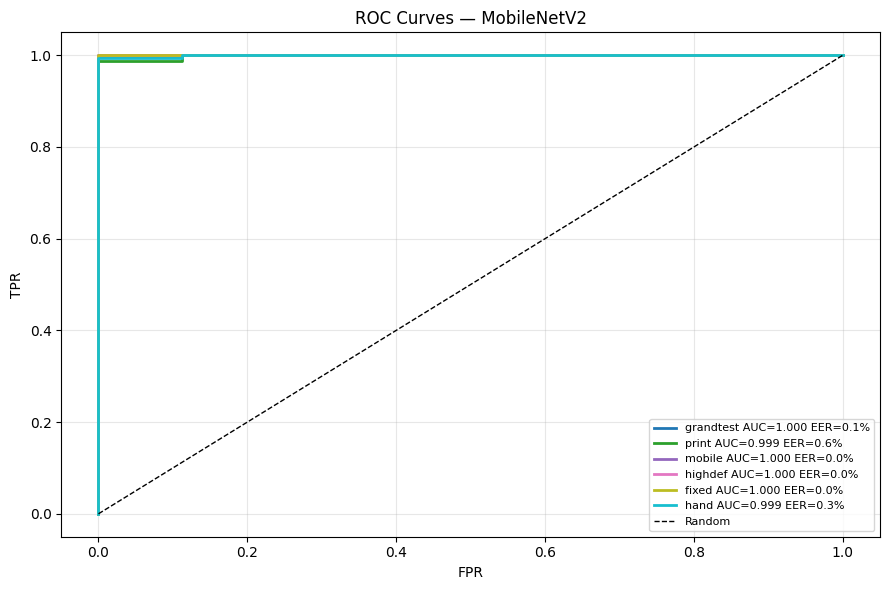

In [26]:
fig, ax = plt.subplots(figsize=(9, 6))
colors = plt.cm.tab10(np.linspace(0, 1, len(results)))
for (name, r), c in zip(results.items(), colors):
    ax.plot(r['fpr'], r['tpr'], color=c, lw=2,
            label=f'{name} AUC={r["auc"]:.3f} EER={r["eer"]*100:.1f}%')
ax.plot([0,1],[0,1],'k--',lw=1,label='Random')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC Curves — MobileNetV2'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('models/mobilenet_roc.png', dpi=150)
plt.show()

## Confusion Matrix (grandtest)

In [ ]:
r = results['grandtest']
cm = confusion_matrix(r['vl'], (r['vs'] >= r['threshold']).astype(int))
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Real','Attack'], yticklabels=['Real','Attack'], ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title(f'Confusion Matrix — MobileNetV2 (grandtest, test) threshold={r["threshold"]:.3f}')
plt.tight_layout()
plt.savefig('models/mobilenet_cm.png', dpi=150)
plt.show()


## Збереження результатів

In [ ]:
# Threshold тепер зберігається в кожному results[proto]['threshold']
save_data = {
    'best_epoch': best_epoch,
    'best_devel_eer': float(best_eer),
    'results': {k: {m: float(v) if not isinstance(v, type(__import__('numpy').array([]))) else v.tolist()
                    for m, v in r.items() if m not in ('fpr','tpr','vs','vl')}
                for k, r in results.items()}
}
with open(MODELS_DIR / 'mobilenet_results.json', 'w') as f:
    json.dump(save_data, f, indent=2)
print('Результати збережено: models/mobilenet_results.json')
print('Модель збережена:     models/mobilenet_best.pth')
